In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [22]:
df= pd.read_csv('../Data/Historical Product Demand.csv')


In [3]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


# Revision DataFrame

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


- Las fechas estan en formato incorrecto
- Existen nulos en card (?)

## Revision datos nulos

In [23]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [24]:
print(f'La cantidad de nulos es {np.max(df.isnull().sum().values)} y el dataframe tiene {df.shape[0]}')

La cantidad de nulos es 11239 y el dataframe tiene 1048575


- En este caso debido a que la cantidad de nulos que representa casi un 1.1 % del total de los datos es correcto eliminarlos

In [25]:
df.dropna(subset=['Date'], inplace=True)

- Existen bastantes nulos los que eliminaremos
- Además también existen otros carácteres que no son números

## Revisando las variables categoricas y numericas si existen problemas

In [32]:
for col in df[['Product_Code', 'Warehouse', 'Order_Demand']].columns:

    print(df[col].unique)

<bound method Series.unique of 0          Product_0993
1          Product_0979
2          Product_0979
3          Product_0979
4          Product_0979
               ...     
1048570    Product_1791
1048571    Product_1974
1048572    Product_1787
1048573    Product_0901
1048574    Product_0704
Name: Product_Code, Length: 1037336, dtype: object>
<bound method Series.unique of 0          Whse_J
1          Whse_J
2          Whse_J
3          Whse_J
4          Whse_J
            ...  
1048570    Whse_J
1048571    Whse_J
1048572    Whse_J
1048573    Whse_J
1048574    Whse_J
Name: Warehouse, Length: 1037336, dtype: object>
<bound method Series.unique of 0           100 
1           500 
2           500 
3           500 
4           500 
           ...  
1048570    1000 
1048571       1 
1048572    2500 
1048573      50 
1048574       4 
Name: Order_Demand, Length: 1037336, dtype: object>


- La única columna que se ve con problemas seria `Order_demand` la que no es numérica y además tiene carácteres como paréntesis

### Eliminando los datos que no sean numeros de la columna order_demand

In [33]:
df['Order_Demand'] = df['Order_Demand'].str.replace(r'[^0-9]', '', regex=True).astype(int)


- Aprovechamos de después de sacar todos los datos no numericos convertir a integer, si está bien entonces no deberia tirar error.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1037336 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1037336 non-null  object
 1   Warehouse         1037336 non-null  object
 2   Product_Category  1037336 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1037336 non-null  int32 
dtypes: int32(1), object(4)
memory usage: 43.5+ MB


## Convirtiendo Date a datetime

In [35]:
df['Date'] = pd.to_datetime(df['Date'])

In [36]:
df.set_index('Date', inplace=True)

# Revisando los estadisticos

In [37]:
df.describe().round(2)

,Order_Demand
count,1037336.00
mean,4949.38
std,29073.44
min,0.00
25%,20.00
50%,300.00
75%,2000.00
max,4000000.00


- Existen datos donde no hay ordenes lo que sugiere que fueron dias donde no se vendió nada.
- El 75 % de los datos se encuentra por debajo de 2000 ordenes pero el valor máximo es de 4000000 lo que es 1999 veces más grande
- En este punto no podriamos ver bien la distribucion ya que por este valor la diferencia de escalas no dejara revisar bien su distribución
     

## Revisando los valores de Order_Demand

C:\Users\kev_g\AppData\Local\Temp\ipykernel_10164\827725282.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Order_Demand'], palette='pastel')


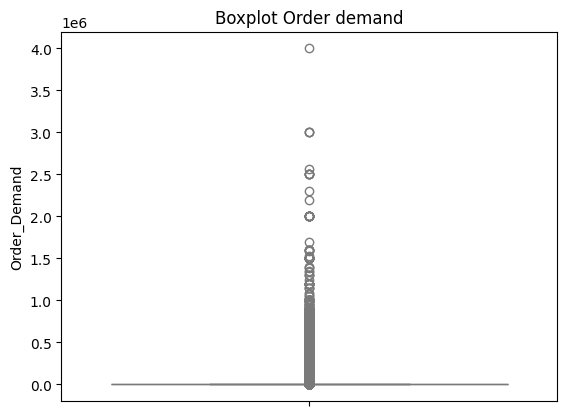

In [67]:
sns.boxplot(df['Order_Demand'], palette='pastel')
plt.title('Boxplot Order demand')
plt.show()


- El gráfico biene a confirmar lo que vimos anteriormente

In [68]:

# Función para revisar la cantidad de datos sobre el valor del valor ingresado
def datos_sobre_thrid_quantile(values: list):

    data = []

    for value in values:
        df_outliers = df[df['Order_Demand'] > value]

        data.append(df_outliers.shape[0])
    return data

datos_sobre_thrid_quantile([2000, 10000, 20000, 1000000])


[235518, 74350, 43741, 76]

- Al parecer los valores grandes no son valores mal ingresados ya que existen bastantes valores después del cuartil 3.

In [83]:
df['Order_Demand_log'] = np.log1p(df['Order_Demand'])

<Axes: xlabel='Order_Demand_log', ylabel='Count'>

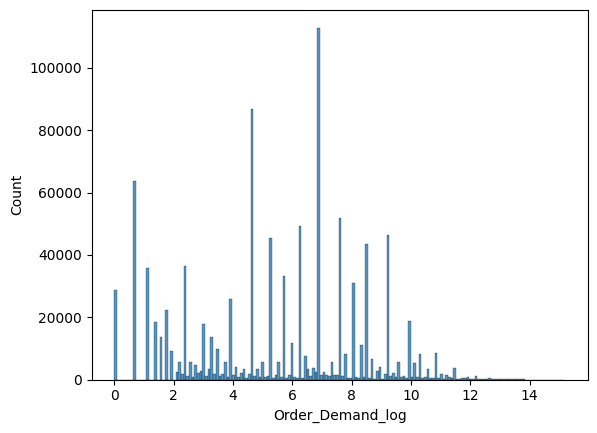

In [85]:
sns.histplot(df['Order_Demand_log'])

In [86]:
y = df['Order_Demand'].resample('W-MON').mean()




In [88]:
y = y.ffill()

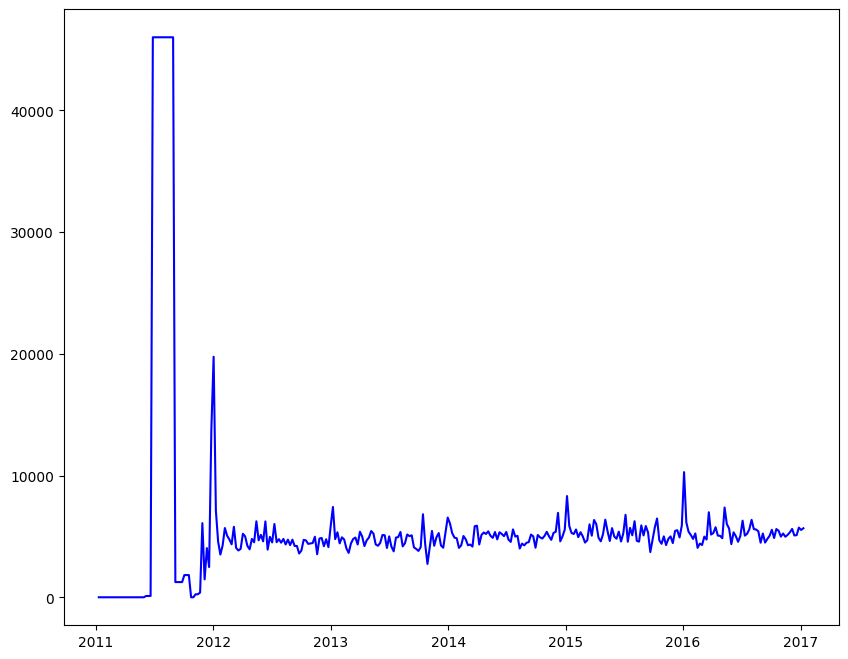

In [89]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.show()


- Considerando que los datos no se ven prometedores con el valor máximo, tomaremos desde finales del 2019 en adelante

In [94]:
y = y[y.index > pd.to_datetime('2012-12-01')]


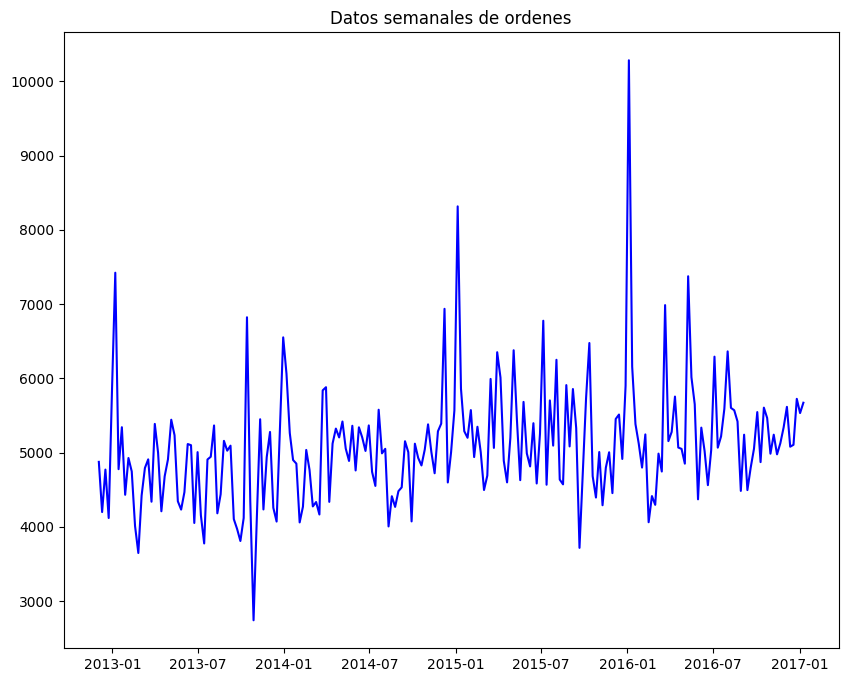

In [96]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.title('Datos semanales de ordenes')
plt.show()

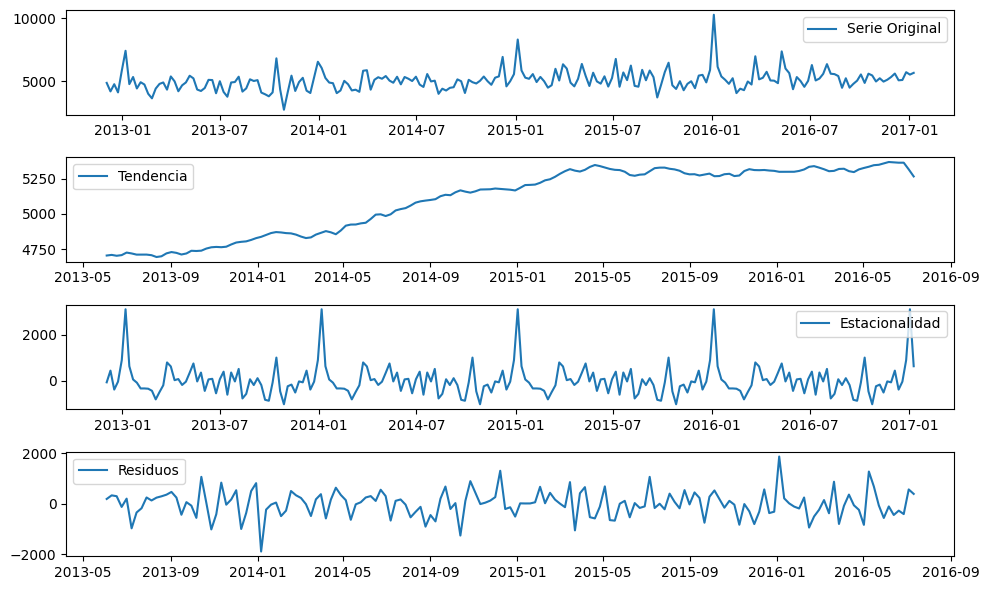

In [97]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(y, model='additive')

# Graficar los componentes
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(y, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()

plt.tight_layout()
plt.show()

- Lo primero que es notorio es que la tendencia es al alza sostenida desde 2013-09 hasta el 2015-04 donde alcanza una meseta más variable.
- Cada año se repite un patron ciclico en los datos donde siempre a principios de año hay un peak muy marcado de ordenes, lo que puede estar ligado algun tipo de promoción a fin de año. Posterior a esto bajan significativamente las ventas volviendo a tener un repunte significativamente mayor que el de principio de año y aún más variable. Considerando esto podemos considerar que cada 52 semanas hay un ciclo.

- Los residuos se encuentran bastante variables pero en general no dan signos más contundentes de seguir patrones

In [98]:
from statsmodels.tsa.stattools import adfuller

# Realizar el test de Dickey-Fuller
result = adfuller(y.values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -11.113799651305158
p-value: 3.604955327677591e-20
Critical Values: {'1%': -3.4612821203214907, '5%': -2.875142613826617, '10%': -2.574020122281422}


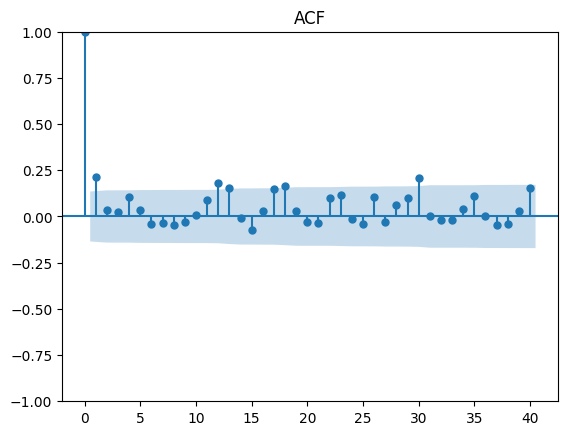

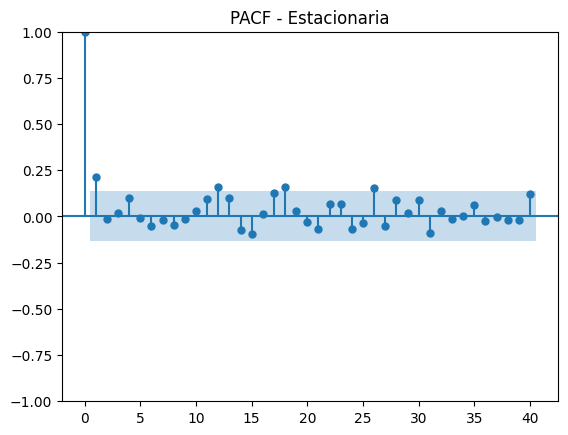

In [29]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(y,  title="ACF", lags='40')
plt.show()
plot_pacf(y, title="PACF - Estacionaria", lags='40')
plt.show()

In [31]:
from statsmodels.tsa.stattools import adfuller

# Realizar la prueba de Dickey-Fuller
adf_result = adfuller(y)
print(f'Estadístico ADF: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

Estadístico ADF: -11.833485215442721
p-value: 7.890088292120355e-22


In [37]:
import statsmodels.api as sm

model = sm.tsa.SARIMAX(y, order=(1, 0, 1), seasonal_order= (1, 1, 0, 52))
results = model.fit()

# Pronóstico para los próximos 'n' pasos
n_pronostico = 52 # Ejemplo: pronóstico para las próximas 52 semanas
pronostico_sarima = results.get_forecast(steps=n_pronostico)
pronostico_intervalo = pronostico_sarima.conf_int()


c:\Proyectos\Pj_1\myenv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2017-01-16    5749.810348
2017-01-23    5016.219988
2017-01-30    5187.884617
2017-02-06    5098.489647
2017-02-13    4493.546771
2017-02-20    4342.265806
2017-02-27    4610.495563
2017-03-06    4859.933950
2017-03-13    5109.927702
2017-03-20    6842.347114
2017-03-27    5513.596622
2017-04-03    5285.787214
2017-04-10    5925.149057
2017-04-17    5005.571702
2017-04-24    5297.280566
2017-05-01    5035.642873
2017-05-08    7578.289549
2017-05-15    5853.125289
2017-05-22    5837.534785
2017-05-29    4432.961107
2017-06-05    5449.115913
2017-06-12    5049.150944
2017-06-19    4717.850876
2017-06-26    5057.605663
2017-07-03    6507.770466
2017-07-10    5061.417619
2017-07-17    5440.922794
2017-07-24    5562.290772
2017-07-31    6582.224327
2017-08-07    5568.278493
2017-08-14    5673.071140
2017-08-21    5504.898125
2017-08-28    4673.988989
2017-09-04    5360.145619
2017-09-11    4702.459564
2017-09-18    4740.742046
2017-09-25    5158.291685
2017-10-02    5592.767844
2017-10-09  

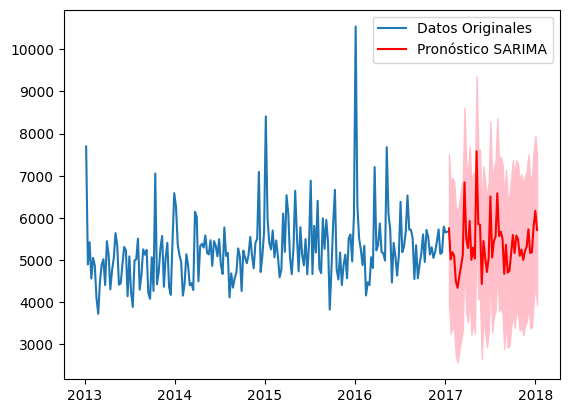

In [38]:
# Imprimir los pronósticos
print(pronostico_sarima.predicted_mean)
print(pronostico_intervalo)

# Puedes graficar los pronósticos y los datos originales si lo deseas
import matplotlib.pyplot as plt

plt.plot(y, label='Datos Originales')
plt.plot(pronostico_sarima.predicted_mean, color='red', label='Pronóstico SARIMA')
plt.fill_between(pronostico_intervalo.index, pronostico_intervalo.iloc[:, 0], pronostico_intervalo.iloc[:, 1], color='pink')
plt.legend()
plt.show()